In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 35.9 MB/s eta 0:00:00


(422997, 28)
     0   1    2      3   4                 5    6      7   8   \
0  2023   8  01A  30001   1  Afognak Lake, AK  A43  30056   1   
1  2023   8  01A  30001   1  Afognak Lake, AK  A43  30056   1   
2  2023   5  01A  30001   1  Afognak Lake, AK  A43  30056   1   
3  2023   6  01A  30001   1  Afognak Lake, AK  A43  30056   1   
4  2023   9  01A  30001   1  Afognak Lake, AK  A43  30056   1   

                  9   ... 18 19    20  21 22  23  24  25  26  27  
0  Kodiak Island, AK  ...  1  0  1200   6  4   0   0  23  21   1  
1  Kodiak Island, AK  ...  1  0   750   5  2   0   0  24  22   1  
2  Kodiak Island, AK  ...  1  0  1200   6  1   0   0  24  22   1  
3  Kodiak Island, AK  ...  3  0  2250  15  1   0   0  64  58   1  
4  Kodiak Island, AK  ...  2  0  2400  12  9   0   0  64  60   1  

[5 rows x 28 columns]

Rows after cleaning: 419155

Top routes:
      origin_airport dest_airport  total_passengers  total_departures  \
13650            JFK          LAX           3574531     

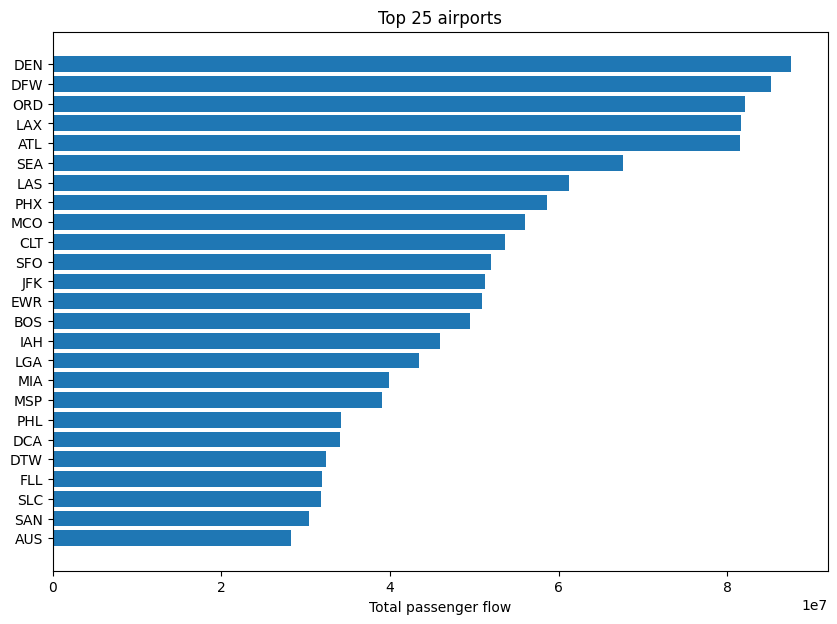

In [ ]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/flightData.asc",
    sep="|",
    header=None,
    engine="python"
)

if df.iloc[:, -1].isna().all() or (df.iloc[:, -1] == "").all():
    df = df.iloc[:, :-1]

print(df.shape)
print(df.head())
df.columns = [
    "year", "month",
    "origin_airport", "origin_airport_id", "origin_state_fips", "origin_city",
    "dest_airport", "dest_airport_id", "dest_state_fips", "dest_city",
    "carrier", "carrier_id",
    "aircraft_group", "distance", "service_class",
    "unknown_1", "aircraft_type", "unknown_2",
    "departures_performed", "departures_scheduled",
    "seats", "payload", "freight", "mail",
    "unknown_3", "passengers",
    "source_field_1", "source_field_2"
]

numeric_cols = [
    "year", "month", "origin_airport_id", "origin_state_fips",
    "dest_airport_id", "dest_state_fips", "aircraft_group",
    "distance", "unknown_1", "aircraft_type", "unknown_2",
    "departures_performed", "departures_scheduled", "seats",
    "payload", "freight", "mail", "unknown_3", "passengers",
    "source_field_1", "source_field_2"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["date"] = pd.to_datetime(
    df["year"].astype("Int64").astype(str) + "-" +
    df["month"].astype("Int64").astype(str).str.zfill(2) + "-01",
    errors="coerce"
)


df = df.dropna(subset=["origin_airport", "dest_airport"])
df = df[(df["origin_airport"] != "") & (df["dest_airport"] != "")]
df_no_self = df[df["origin_airport"] != df["dest_airport"]].copy()

print("\nRows after cleaning:", len(df_no_self))


route_edges = (
    df_no_self
    .groupby(["origin_airport", "dest_airport"], as_index=False)
    .agg(
        total_passengers=("passengers", "sum"),
        total_departures=("departures_performed", "sum"),
        total_seats=("seats", "sum"),
        avg_distance=("distance", "mean"),
        n_records=("origin_airport", "size")
    )
)

print("\nTop routes:")
print(route_edges.sort_values("total_passengers", ascending=False).head(10))


G = nx.DiGraph()

for _, row in route_edges.iterrows():
    G.add_edge(
        row["origin_airport"],
        row["dest_airport"],
        passengers=row["total_passengers"]
    )

print("\nGraph summary")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

out_strength = dict(G.out_degree(weight="passengers"))
in_strength = dict(G.in_degree(weight="passengers"))

betweenness = nx.betweenness_centrality(G, normalized=True)

pagerank = nx.pagerank(G, weight="passengers")

metrics = pd.DataFrame({
    "airport": list(G.nodes())
})

metrics["out_passengers"] = metrics["airport"].map(out_strength).fillna(0)
metrics["in_passengers"] = metrics["airport"].map(in_strength).fillna(0)
metrics["total_passengers"] = metrics["out_passengers"] + metrics["in_passengers"]
metrics["betweenness"] = metrics["airport"].map(betweenness).fillna(0)
metrics["pagerank"] = metrics["airport"].map(pagerank).fillna(0)

print("\nTop airports by traffic:")
print(metrics.sort_values("total_passengers", ascending=False).head(15))

top25 = metrics.sort_values("total_passengers", ascending=False).head(25)

plt.figure(figsize=(10, 7))
plt.barh(top25["airport"], top25["total_passengers"])
plt.gca().invert_yaxis()
plt.xlabel("Total passenger flow")
plt.title("Top 25 airports")
plt.show()

In [ ]:
top25 = (
    metrics.sort_values("total_passengers", ascending=False)
    .head(25)["airport"]
    .tolist()
)

edges_top25 = route_edges[
    route_edges["origin_airport"].isin(top25) &
    route_edges["dest_airport"].isin(top25)
]

matrix = edges_top25.pivot_table(
    index="origin_airport",
    columns="dest_airport",
    values="total_passengers",
    fill_value=0
)

matrix = matrix.reindex(index=top25, columns=top25, fill_value=0)

print(matrix)

dest_airport          DEN        DFW        ORD        LAX        ATL  \
origin_airport                                                          
DEN                   0.0   736095.0   913186.0  1063514.0  1048933.0   
DFW              803657.0        0.0   840156.0  1333815.0   817566.0   
ORD              984358.0   893432.0        0.0  1743237.0   683321.0   
LAX              983528.0  1229272.0  1570597.0        0.0  1374219.0   
ATL             1199971.0   931796.0   734602.0  1557581.0        0.0   
SEA             1052430.0   961340.0  1150360.0  1317441.0   990705.0   
LAS             1017304.0   963209.0  1124123.0   803974.0  1161974.0   
PHX             1009013.0   704588.0  1195859.0   611842.0   735082.0   
MCO             1107086.0   930804.0   965078.0  1032530.0   877630.0   
CLT              653813.0   657535.0   548363.0   826847.0   356135.0   
SFO              812173.0   805796.0  1178332.0  1029360.0   869794.0   
JFK              362758.0   427261.0   441871.0  35


Top airports by betweenness:
    airport  betweenness  total_passengers  pagerank
71      ANC     0.279965          20448470  0.020232
54      FAI     0.064821           3463558  0.009116
28      HPN     0.048481           4470863  0.005077
275     SEA     0.047020          67653362  0.023623
200     TEB     0.040284            308170  0.003057
1       A43     0.036520             69556  0.008494
81      KLN     0.033894             81842  0.000610
185     ORD     0.033703          82141885  0.025225
430     BFI     0.031055            966426  0.001575
152     DEN     0.030245          87530850  0.026885
181     MSP     0.027574          39102955  0.011615
15      VNY     0.027091            208098  0.001778
210     DFW     0.025268          85131821  0.026799
257     LAS     0.024408          61260721  0.017821
22      IAD     0.023610          21696372  0.006339
37      PHX     0.022679          58660658  0.017903
258     LAX     0.020840          81594267  0.022736
279     SLC     

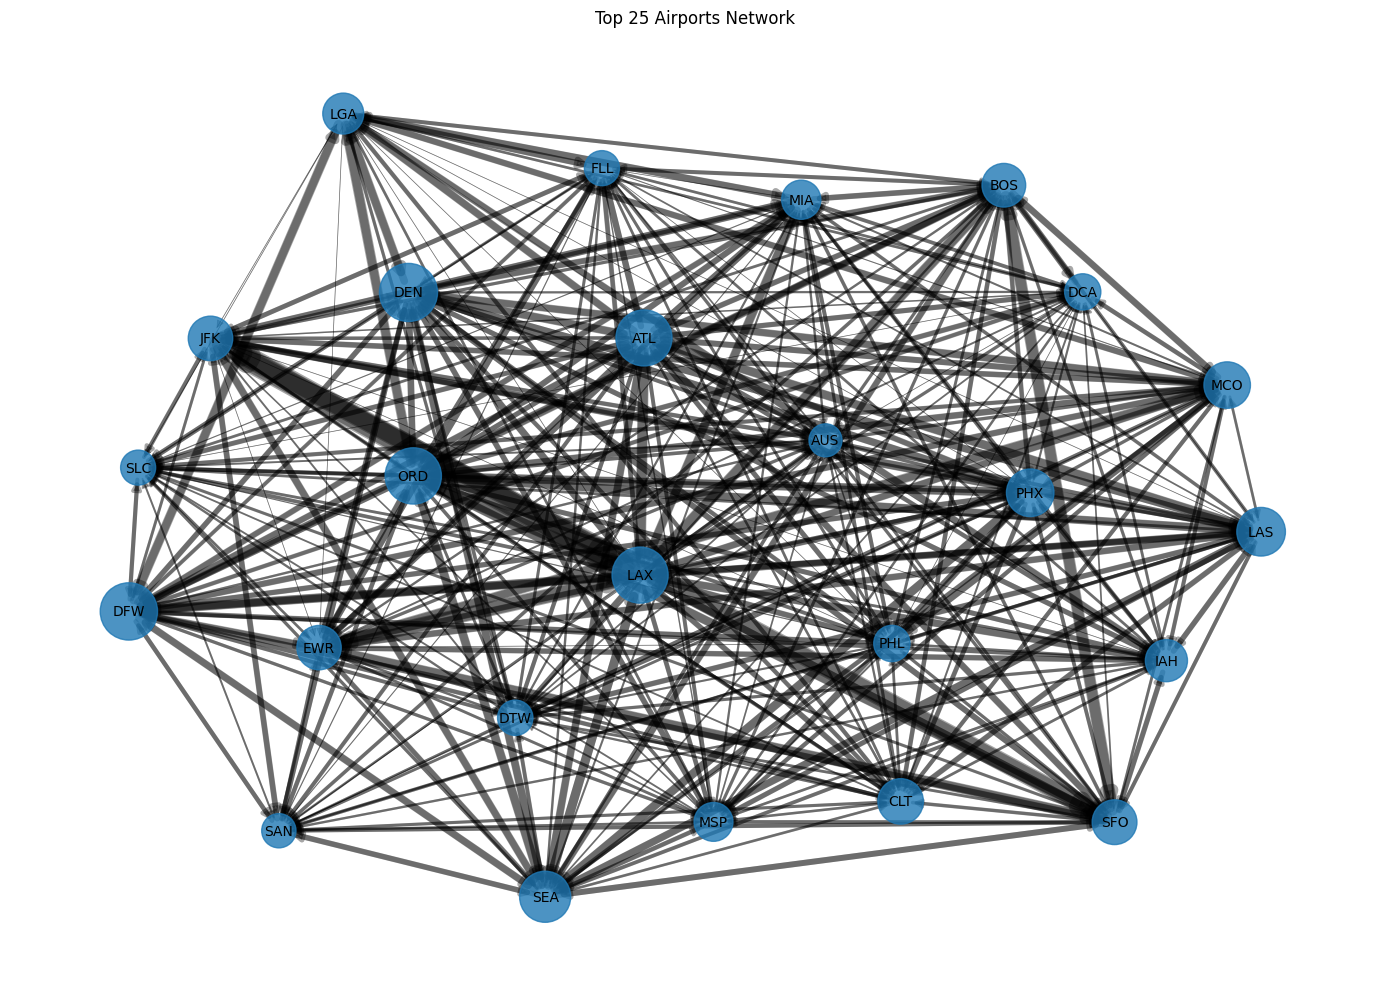

In [ ]:
print("\nTop airports by betweenness:")
betweenness_table = metrics.sort_values("betweenness", ascending=False).head(25)
print(betweenness_table[["airport", "betweenness", "total_passengers", "pagerank"]])
betweenness_table.to_csv("top25_betweenness.csv", index=False)

top25_airports = (
    metrics.sort_values("total_passengers", ascending=False)
    .head(25)["airport"]
    .tolist()
)

G_top25 = G.subgraph(top25_airports).copy()

print("\nTop-25 subgraph summary")
print("Nodes:", G_top25.number_of_nodes())
print("Edges:", G_top25.number_of_edges())

top25_metric_map = metrics.set_index("airport")
node_sizes = [
    top25_metric_map.loc[node, "total_passengers"] / 50000
    for node in G_top25.nodes()
]

edge_widths = [
    max(G_top25[u][v]["passengers"] / 200000, 0.5)
    for u, v in G_top25.edges()
]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_top25, k=1.2, seed=42)

nx.draw_networkx_nodes(
    G_top25,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_top25,
    pos,
    width=edge_widths,
    alpha=0.35,
    arrows=True,
    arrowsize=12
)

nx.draw_networkx_labels(
    G_top25,
    pos,
    font_size=10
)

plt.title("Top 25 Airports Network")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

airport_coords = {
    "DEN": (39.8561, -104.6737),
    "DFW": (32.8998, -97.0403),
    "ORD": (41.9742, -87.9073),
    "LAX": (33.9416, -118.4085),
    "ATL": (33.6407, -84.4277),
    "SEA": (47.4502, -122.3088),
    "LAS": (36.0840, -115.1537),
    "PHX": (33.4342, -112.0116),
    "MCO": (28.4312, -81.3081),
    "CLT": (35.2140, -80.9431),
    "SFO": (37.6213, -122.3790),
    "JFK": (40.5, -71.5),
    "EWR": (39, -73),
    "BOS": (42.3656, -71.0096),
    "IAH": (29.9902, -95.3368),
    "LGA": (41, -73),
    "MIA": (25.7959, -80.2870),
    "MSP": (44.8848, -93.2223),
    "PHL": (39.8744, -75.2424),
    "DCA": (38, -77.5),
    "DTW": (42.2162, -83.3554),
    "FLL": (26.0726, -80.1527),
    "SLC": (40.7899, -111.9791),
    "SAN": (32.7338, -117.1933),
    "AUS": (30.1975, -97.6664),
}
#"JFK": (40.6413, -73.7781),
#"EWR": (40.6895, -74.1745),
#"DCA": (38.8512, -77.0402),

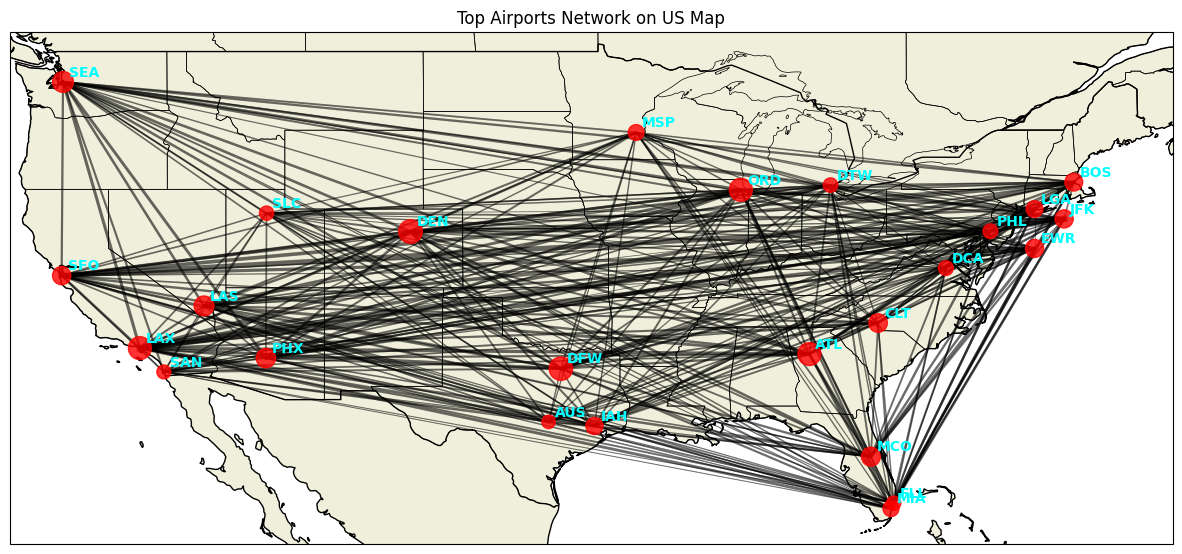

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

top_airports = (
    metrics.sort_values("total_passengers", ascending=False)
    .head(25)
    .copy()
)

top_airports["lat"] = top_airports["airport"].map(lambda x: airport_coords.get(x, (None, None))[0])
top_airports["lon"] = top_airports["airport"].map(lambda x: airport_coords.get(x, (None, None))[1])
top_airports = top_airports.dropna(subset=["lat", "lon"])

mapped_codes = set(top_airports["airport"])

edges_top = route_edges[
    route_edges["origin_airport"].isin(mapped_codes) &
    route_edges["dest_airport"].isin(mapped_codes)
]

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)

weights = edges_top["total_passengers"]
min_w = weights.min()
max_w = weights.max()

def scale_width(w):
    if max_w == min_w:
        return 2
    return 0.5 + 4.5 * (w - min_w) / (max_w - min_w)

for _, row in edges_top.iterrows():
    lat1, lon1 = airport_coords[row["origin_airport"]]
    lat2, lon2 = airport_coords[row["dest_airport"]]

    ax.plot(
        [lon1, lon2],
        [lat1, lat2],
        color="black",
        alpha=0.35,
        linewidth=scale_width(row["total_passengers"]),
        zorder=1,
        transform=ccrs.PlateCarree()
    )

ax.scatter(
    top_airports["lon"],
    top_airports["lat"],
    s=top_airports["total_passengers"] / 300000,
    color="red",
    alpha=0.8,
    zorder=2,
    transform=ccrs.PlateCarree()
)

for _, row in top_airports.iterrows():
    ax.text(
        row["lon"] + 0.3,
        row["lat"] + 0.3,
        row["airport"],
        fontsize=10,
        weight="bold",
        color="#00FFFF",  # neon blue / cyan
        zorder=3,
        transform=ccrs.PlateCarree()
    )
plt.title("Top Airports Network on US Map")
plt.show()

In [ ]:
def max_shortest_path_length(G):
    lengths = dict(nx.all_pairs_shortest_path_length(G))

    max_dist = 0

    for u in G.nodes():
        for v in G.nodes():
            if u == v:
                continue

            if v not in lengths[u]:
                return float("inf")

            max_dist = max(max_dist, lengths[u][v])

    return max_dist

def one_connection_property(G):
    return max_shortest_path_length(G) <= 2

G_top25 = G.subgraph(top25).copy()

G_test = G_top25.copy()

removed_edges = []

edges_sorted = sorted(
    G_test.edges(data=True),
    key=lambda x: x[2].get("passengers", 0)
)

for i, (u, v, data) in enumerate(edges_sorted):
    if i % 10 == 0:
        print(f"Checking edge {i}/{len(edges_sorted)}")

    G_temp = G_test.copy()
    G_temp.remove_edge(u, v)

    if one_connection_property(G_temp):
        G_test.remove_edge(u, v)
        removed_edges.append((u, v, data.get("passengers", 0)))

print("Original top-25 edges:", G_top25.number_of_edges())
print("Remaining edges:", G_test.number_of_edges())
print("Edges removed:", len(removed_edges))
print("Maximum distance after removal:", max_shortest_path_length(G_test))

Checking edge 0/591
Checking edge 10/591
Checking edge 20/591
Checking edge 30/591
Checking edge 40/591
Checking edge 50/591
Checking edge 60/591
Checking edge 70/591
Checking edge 80/591
Checking edge 90/591
Checking edge 100/591
Checking edge 110/591
Checking edge 120/591
Checking edge 130/591
Checking edge 140/591
Checking edge 150/591
Checking edge 160/591
Checking edge 170/591
Checking edge 180/591
Checking edge 190/591
Checking edge 200/591
Checking edge 210/591
Checking edge 220/591
Checking edge 230/591
Checking edge 240/591
Checking edge 250/591
Checking edge 260/591
Checking edge 270/591
Checking edge 280/591
Checking edge 290/591
Checking edge 300/591
Checking edge 310/591
Checking edge 320/591
Checking edge 330/591
Checking edge 340/591
Checking edge 350/591
Checking edge 360/591
Checking edge 370/591
Checking edge 380/591
Checking edge 390/591
Checking edge 400/591
Checking edge 410/591
Checking edge 420/591
Checking edge 430/591
Checking edge 440/591
Checking edge 450/591

In [ ]:
removed_df = pd.DataFrame(
    removed_edges,
    columns=["origin", "destination", "passengers"]
)

print(removed_df.sort_values("passengers").head(20))

   origin destination  passengers
0     LGA         EWR         146
1     EWR         LGA         614
2     LGA         JFK        1880
3     JFK         EWR        2323
4     LGA         AUS        2799
5     EWR         JFK        2877
6     PHX         LGA        3855
7     JFK         LGA        4528
8     FLL         MIA        4871
9     LGA         PHX        5330
10    LAX         LGA        5630
11    LAS         LGA        5679
12    PHL         JFK        5809
13    JFK         PHL        6151
14    MIA         FLL        6435
15    LGA         LAX        6567
16    LGA         LAS        7946
17    SLC         LGA        9790
18    LGA         SLC       12508
19    LGA         PHL       18014


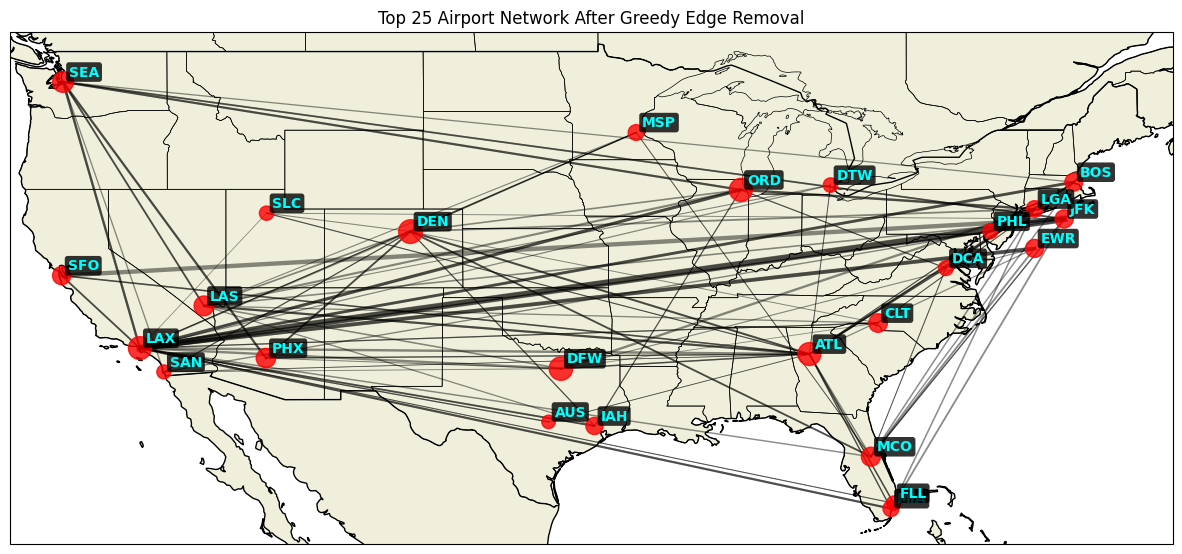

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
top_airports = (
    metrics.sort_values("total_passengers", ascending=False)
    .head(25)
    .copy()
)

top_airports["lat"] = top_airports["airport"].map(lambda x: airport_coords.get(x, (None, None))[0])
top_airports["lon"] = top_airports["airport"].map(lambda x: airport_coords.get(x, (None, None))[1])
top_airports = top_airports.dropna(subset=["lat", "lon"])

edges_top_removed = []

for u, v, data in G_test.edges(data=True):
    edges_top_removed.append({
        "origin_airport": u,
        "dest_airport": v,
        "total_passengers": data.get("passengers", 0)
    })

edges_top_removed = pd.DataFrame(edges_top_removed)


for u, v, data in G_top25.edges(data=True):
    if not G_test.has_edge(u, v):
        removed_edges_to_plot.append({
            "origin_airport": u,
            "dest_airport": v,
            "total_passengers": data.get("passengers", 0)
        })

removed_edges_to_plot = pd.DataFrame(removed_edges_to_plot)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)

weights = edges_top_removed["total_passengers"]

min_w = weights.min()
max_w = weights.max()

def scale_width(w):
    if max_w == min_w:
        return 2
    return 0.5 + 4.5 * (w - min_w) / (max_w - min_w)

for _, row in edges_top_removed.iterrows():
    lat1, lon1 = airport_coords[row["origin_airport"]]
    lat2, lon2 = airport_coords[row["dest_airport"]]

    ax.plot(
        [lon1, lon2],
        [lat1, lat2],
        color="black",
        alpha=0.45,
        linewidth=scale_width(row["total_passengers"]),
        zorder=1,
        transform=ccrs.PlateCarree()
    )
ax.scatter(
    top_airports["lon"],
    top_airports["lat"],
    s=top_airports["total_passengers"] / 300000,
    color="red",
    alpha=0.8,
    zorder=3,
    transform=ccrs.PlateCarree()
)

for _, row in top_airports.iterrows():
    ax.text(
        row["lon"] + 0.3,
        row["lat"] + 0.3,
        row["airport"],
        fontsize=10,
        weight="bold",
        color="#00FFFF",
        zorder=4,
        transform=ccrs.PlateCarree(),
        bbox=dict(
            facecolor="black",
            edgecolor="none",
            boxstyle="round,pad=0.2",
            alpha=0.8
        )
    )

plt.title("Top 25 Airport Network After Greedy Edge Removal")
plt.show()

Top-25 nodes: 25
Top-25 directed edges: 591
Passenger attack edges: 591
Betweenness attack edges: 591
                                 strategy  edges_removed  \
0  Highest passenger routes removed first              0   
1  Highest passenger routes removed first              1   
2  Highest passenger routes removed first              2   
3  Highest passenger routes removed first              3   
4  Highest passenger routes removed first              4   

   largest_component_frac  num_components  avg_shortest_path  \
0                     1.0               1           1.013333   
1                     1.0               1           1.013333   
2                     1.0               1           1.016667   
3                     1.0               1           1.016667   
4                     1.0               1           1.020000   

   remaining_passenger_frac  
0                  1.000000  
1                  0.989978  
2                  0.981105  
3                  0.973612  
4 

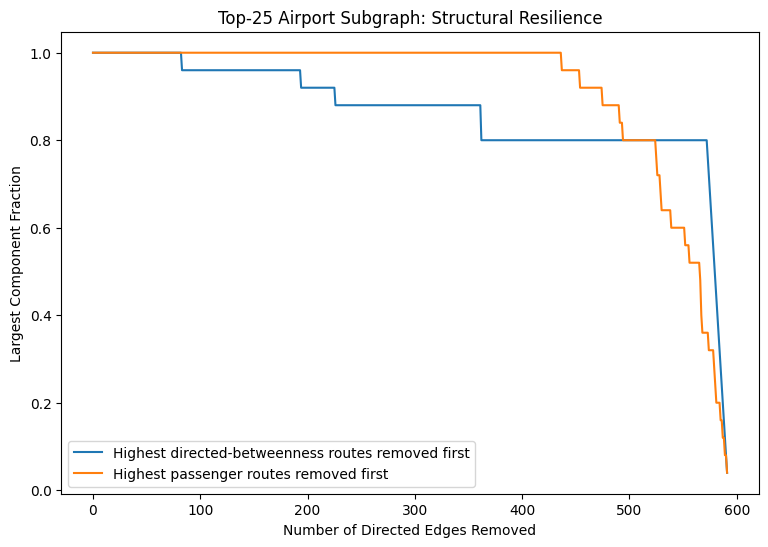

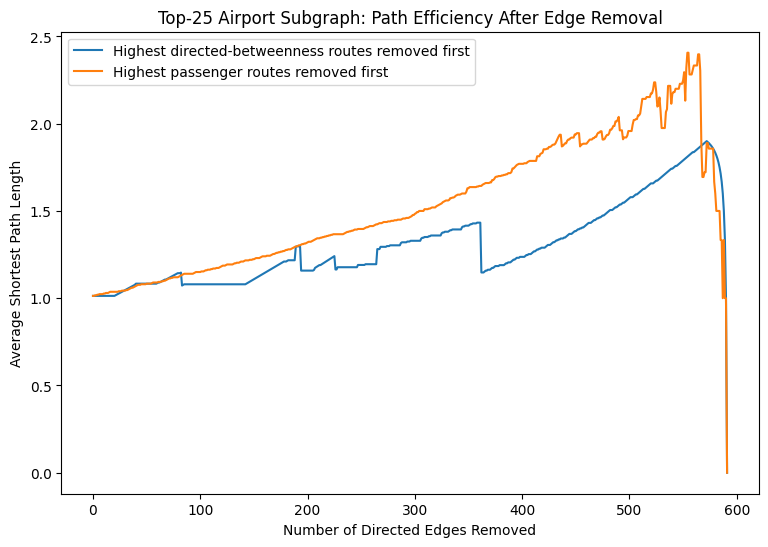

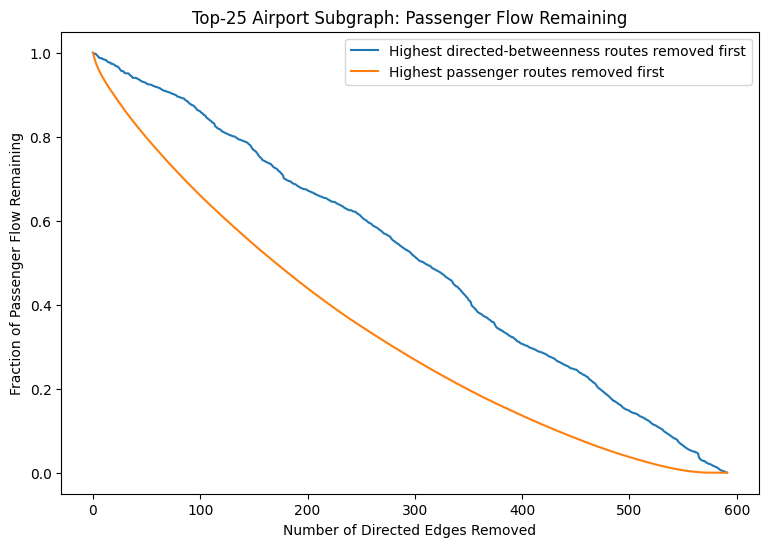

In [ ]:
G_top25 = G.subgraph(top25).copy()

def component_stats(G_current):
    UG = G_current.to_undirected()

    if UG.number_of_nodes() == 0:
        return {
            "largest_component_frac": 0,
            "num_components": 0,
            "avg_shortest_path": float("inf"),
            "remaining_passengers": 0
        }

    components = list(nx.connected_components(UG))
    largest_cc = max(components, key=len)
    H = UG.subgraph(largest_cc).copy()

    if H.number_of_nodes() > 1:
        avg_path = nx.average_shortest_path_length(H)
    else:
        avg_path = 0

    remaining_passengers = sum(
        data.get("passengers", 0)
        for _, _, data in G_current.edges(data=True)
    )

    return {
        "largest_component_frac": len(largest_cc) / UG.number_of_nodes(),
        "num_components": len(components),
        "avg_shortest_path": avg_path,
        "remaining_passengers": remaining_passengers
    }


def run_edge_attack(G_base, edge_order, label):
    G_current = G_base.copy()
    results = []

    original_passengers = sum(
        data.get("passengers", 0)
        for _, _, data in G_base.edges(data=True)
    )

    stats = component_stats(G_current)
    results.append({
        "strategy": label,
        "edges_removed": 0,
        "largest_component_frac": stats["largest_component_frac"],
        "num_components": stats["num_components"],
        "avg_shortest_path": stats["avg_shortest_path"],
        "remaining_passenger_frac": stats["remaining_passengers"] / original_passengers
    })

    for k, (u, v) in enumerate(edge_order, start=1):
        if G_current.has_edge(u, v):
            G_current.remove_edge(u, v)

        stats = component_stats(G_current)

        results.append({
            "strategy": label,
            "edges_removed": k,
            "largest_component_frac": stats["largest_component_frac"],
            "num_components": stats["num_components"],
            "avg_shortest_path": stats["avg_shortest_path"],
            "remaining_passenger_frac": stats["remaining_passengers"] / original_passengers
        })

    return pd.DataFrame(results)

edges_by_passengers = sorted(
    G_top25.edges(data=True),
    key=lambda x: x[2].get("passengers", 0),
    reverse=True
)

edges_by_passengers = [
    (u, v)
    for u, v, data in edges_by_passengers
]

edge_betweenness = nx.edge_betweenness_centrality(
    G_top25,
    normalized=True,
    weight=None
)

edges_by_betweenness = sorted(
    edge_betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)

edges_by_betweenness = [
    (u, v)
    for (u, v), score in edges_by_betweenness
]


print("Top-25 nodes:", G_top25.number_of_nodes())
print("Top-25 directed edges:", G_top25.number_of_edges())
print("Passenger attack edges:", len(edges_by_passengers))
print("Betweenness attack edges:", len(edges_by_betweenness))

passenger_attack_df = run_edge_attack(
    G_top25,
    edges_by_passengers,
    "Highest passenger routes removed first"
)

betweenness_attack_df = run_edge_attack(
    G_top25,
    edges_by_betweenness,
    "Highest directed-betweenness routes removed first"
)

attack_df = pd.concat(
    [passenger_attack_df, betweenness_attack_df],
    ignore_index=True
)

print(attack_df.head())
print(attack_df.tail())
plt.figure(figsize=(9, 6))

for strategy, group in attack_df.groupby("strategy"):
    plt.plot(
        group["edges_removed"],
        group["largest_component_frac"],
        label=strategy
    )

plt.xlabel("Number of Directed Edges Removed")
plt.ylabel("Largest Component Fraction")
plt.title("Top-25 Airport Subgraph: Structural Resilience")
plt.legend()
plt.show()

plt.figure(figsize=(9, 6))

for strategy, group in attack_df.groupby("strategy"):
    plt.plot(
        group["edges_removed"],
        group["avg_shortest_path"],
        label=strategy
    )

plt.xlabel("Number of Directed Edges Removed")
plt.ylabel("Average Shortest Path Length")
plt.title("Top-25 Airport Subgraph: Path Efficiency After Edge Removal")
plt.legend()
plt.show()

plt.figure(figsize=(9, 6))

for strategy, group in attack_df.groupby("strategy"):
    plt.plot(
        group["edges_removed"],
        group["remaining_passenger_frac"],
        label=strategy
    )

plt.xlabel("Number of Directed Edges Removed")
plt.ylabel("Fraction of Passenger Flow Remaining")
plt.title("Top-25 Airport Subgraph: Passenger Flow Remaining")
plt.legend()
plt.show()

In [ ]:
betweenness_nodes = nx.betweenness_centrality(
    G_top25,
    normalized=True,
    weight=None  # unweighted shortest paths
)

betweenness_df = pd.DataFrame({
    "airport": list(betweenness_nodes.keys()),
    "betweenness": list(betweenness_nodes.values())
})

betweenness_df = betweenness_df.sort_values(
    "betweenness",
    ascending=False
)

print("\nTop-25 airports by betweenness centrality:")
print(betweenness_df)


Top-25 airports by betweenness centrality:
   airport  betweenness
0      FLL     0.000795
1      LAS     0.000795
4      BOS     0.000795
6      IAH     0.000795
5      DEN     0.000795
8      ORD     0.000795
12     MIA     0.000795
11     EWR     0.000795
9      LAX     0.000795
21     JFK     0.000795
18     MSP     0.000795
19     PHX     0.000795
13     SLC     0.000795
15     PHL     0.000795
14     CLT     0.000795
16     ATL     0.000795
17     MCO     0.000795
24     DTW     0.000795
20     DFW     0.000795
23     DCA     0.000444
22     AUS     0.000428
2      SEA     0.000165
10     SFO     0.000165
7      SAN     0.000000
3      LGA     0.000000
